In [ ]:
# ----------------------------------------------------
# Title: Malware Detection Using Logistic Regression and Naive Bayes
# Author: Ehsan Saleh
# Course: Supervised Machine Learning
# Instructor: Dr. Ehsan Nazerfard
# Program: MCI AI Bootcamp (Generative AI with a Focus on Image Processing and Analysis)
# ----------------------------------------------------

from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the main dataset (assumed to be in the root of MyDrive)
# Adjust the path if the file is inside a specific folder, e.g., '/content/drive/MyDrive/my_folder/anti-malware .csv'
input_path = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 3/anti-malware .csv'

# Check if the file exists at the specified path
if os.path.exists(input_path):
    print("Dataset successfully found!")
else:
    print("Error: Dataset not found. Please check the path in input_path variable.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset successfully found!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# 1. Load the dataset
print("Loading the original dataset...")
df = pd.read_csv(input_path)
df.columns = df.columns.str.strip() # Clear any trailing/leading whitespaces from column names
target_col = 'OUTPUT'

print(f"Original dataset shape: {df.shape}")

# Define the output directory in Google Drive
output_dir = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 3/'


# -------------------------------------------------------------------------
# Part 3: Select top 30 columns based on Mutual Information (Dependency)
# -------------------------------------------------------------------------
print("\n--- Part 3: Selecting Top 30 Columns using Mutual Information ---")
X = df.drop(columns=[target_col])
y = df[target_col]

# Apply SelectKBest algorithm to find the most informative features
selector = SelectKBest(score_func=mutual_info_classif, k=30)
X_best = selector.fit_transform(X, y)
top_30_features = X.columns[selector.get_support()].tolist()

df_top_30 = df[top_30_features + [target_col]].copy()

path_part3 = output_dir + 'malware_top_30_dependencies.csv'
df_top_30.to_csv(path_part3, index=False)

print("Top 30 selected features:")
for i, feature in enumerate(top_30_features, 1):
    print(f"{i}. {feature}")

print(f"\nPart 3 final file saved with 31 columns at:\n{path_part3}")
print("\nProcess completed successfully!")

Loading the original dataset...
Original dataset shape: (11261, 312)

--- Part 3: Selecting Top 30 Columns using Mutual Information ---
Top 30 selected features:
1. NtDuplicateObject
2. CoUninitialize
3. RegCloseKey
4. LdrUnloadDll
5. GetSystemWindowsDirectoryW
6. NtClose
7. RegQueryValueExW
8. GetSystemMetrics
9. NtMapViewOfSection
10. CreateActCtxW
11. RegOpenKeyExW
12. NtAllocateVirtualMemory
13. RegOpenKeyExA
14. LdrGetDllHandle
15. NtUnmapViewOfSection
16. GetSystemDirectoryW
17. FindResourceExW
18. NtFreeVirtualMemory
19. GetSystemTimeAsFileTime
20. CoInitializeEx
21. LoadStringW
22. NtOpenKey
23. LdrGetProcedureAddress
24. LdrLoadDll
25. NtQueryValueKey
26. GetFileAttributesW
27. NtDelayExecution
28. SetErrorMode
29. NtReadFile
30. MessageBoxTimeoutW

Part 3 final file saved with 31 columns at:
/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 3/malware_top_30_dependencies.csv

Process completed successfully!


--- Class Distribution ---
Class 1: 8862 samples (78.70%)
Class 0: 2399 samples (21.30%)


/tmp/ipykernel_2250/3393284006.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='OUTPUT', data=df_top30, palette='Set2')


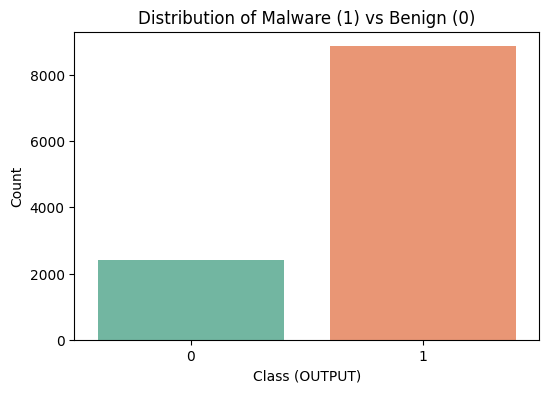

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the top 30 features dataset from Google Drive
file_part3 = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 3/malware_top_30_dependencies.csv'
df_top30 = pd.read_csv(file_part3)

# 1. Count the number of 0s and 1s
class_counts = df_top30['OUTPUT'].value_counts()
class_percentages = df_top30['OUTPUT'].value_counts(normalize=True) * 100

print("--- Class Distribution ---")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples ({class_percentages[cls]:.2f}%)")

# 2. Plot the distribution for better visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='OUTPUT', data=df_top30, palette='Set2')
plt.title('Distribution of Malware (1) vs Benign (0)')
plt.xlabel('Class (OUTPUT)')
plt.ylabel('Count')
plt.show()

Starting 5-Fold Cross Validation with Detailed Metrics...

======================= FOLD 1 =======================
Overall Accuracy: 0.9285
Class       Precision   Recall      F1-Score    
Benign (0)  0.8004      0.8854      0.8408      
Malware (1) 0.9681      0.9402      0.9539      


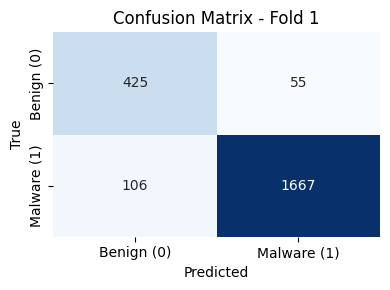

-------------------------------------------------------

======================= FOLD 2 =======================
Overall Accuracy: 0.9170
Class       Precision   Recall      F1-Score    
Benign (0)  0.7765      0.8559      0.8143      
Malware (1) 0.9600      0.9334      0.9465      


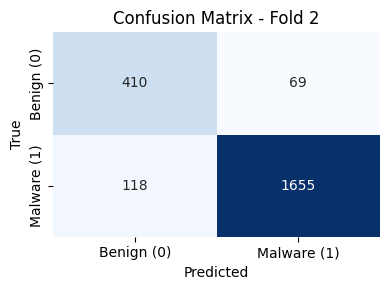

-------------------------------------------------------

======================= FOLD 3 =======================
Overall Accuracy: 0.9303
Class       Precision   Recall      F1-Score    
Benign (0)  0.8076      0.8833      0.8438      
Malware (1) 0.9676      0.9430      0.9551      


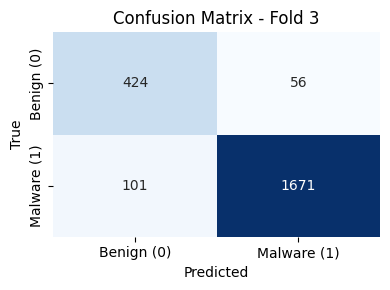

-------------------------------------------------------

======================= FOLD 4 =======================
Overall Accuracy: 0.9347
Class       Precision   Recall      F1-Score    
Benign (0)  0.8271      0.8771      0.8514      
Malware (1) 0.9662      0.9503      0.9582      


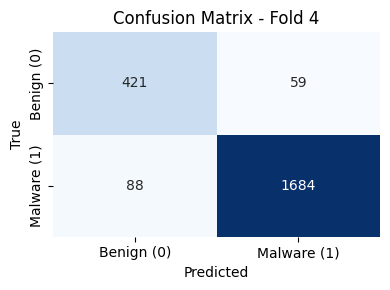

-------------------------------------------------------

======================= FOLD 5 =======================
Overall Accuracy: 0.9365
Class       Precision   Recall      F1-Score    
Benign (0)  0.8285      0.8854      0.8560      
Malware (1) 0.9684      0.9503      0.9593      


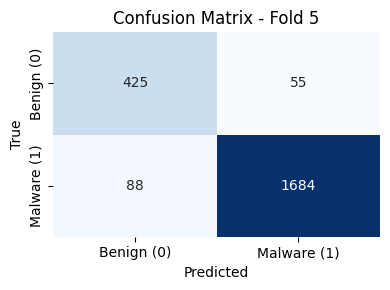

-------------------------------------------------------


==================== FINAL 5-FOLD AVERAGE REPORT ====================
Mean Accuracy: 0.9294 (+/- 0.0069)
------------------------------------------------------------
Metric              Benign (Class 0)      Malware (Class 1)     
Mean Precision      0.8080                0.9660                
Mean Recall         0.8774                0.9435                
Mean F1-Score       0.8412                0.9546                


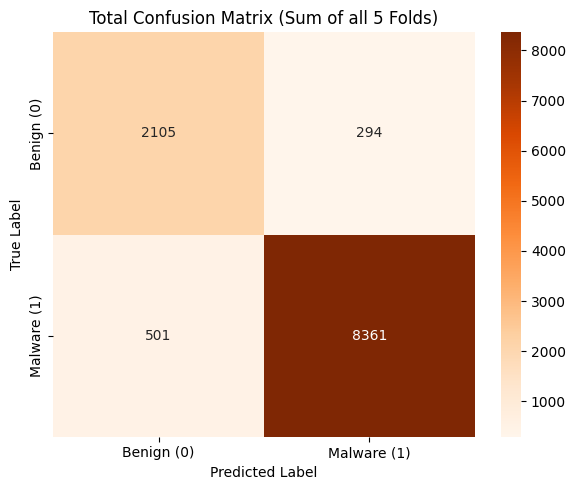

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

# 1. Load the top 30 features dataset
file_part3 = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 3/malware_top_30_dependencies.csv'
df_top30 = pd.read_csv(file_part3)

# Separate features (X) and target (y)
X = df_top30.drop(columns=['OUTPUT']).values
y = df_top30['OUTPUT'].values

# 2. Setup Stratified 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionaries to store all metrics across folds for final averaging
metrics_history = {
    'accuracy': [],
    'precision_0': [], 'precision_1': [],
    'recall_0': [], 'recall_1': [],
    'f1_0': [], 'f1_1': []
}

# Cumulative confusion matrix for the final plot
combined_cm = np.zeros((2, 2), dtype=int)

print("Starting 5-Fold Cross Validation with Detailed Metrics...\n")

# 3. Loop through each fold
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Normalize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train Logistic Regression
    log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
    log_reg.fit(X_train_scaled, y_train)

    # Predict
    y_pred = log_reg.predict(X_test_scaled)

    # Calculate Metrics
    fold_acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=[0, 1])
    fold_cm = confusion_matrix(y_test, y_pred)

    # Save to history
    metrics_history['accuracy'].append(fold_acc)
    metrics_history['precision_0'].append(precision[0])
    metrics_history['precision_1'].append(precision[1])
    metrics_history['recall_0'].append(recall[0])
    metrics_history['recall_1'].append(recall[1])
    metrics_history['f1_0'].append(f1[0])
    metrics_history['f1_1'].append(f1[1])

    combined_cm += fold_cm

    # --- Print Individual Fold Metrics Table ---
    print(f"======================= FOLD {fold} =======================")
    print(f"Overall Accuracy: {fold_acc:.4f}")
    print(f"{'Class':<12}{'Precision':<12}{'Recall':<12}{'F1-Score':<12}")
    print(f"{'Benign (0)':<12}{precision[0]:<12.4f}{recall[0]:<12.4f}{f1[0]:<12.4f}")
    print(f"{'Malware (1)':<12}{precision[1]:<12.4f}{recall[1]:<12.4f}{f1[1]:<12.4f}")

    # Plot Confusion Matrix for this fold
    plt.figure(figsize=(4, 3))
    sns.heatmap(fold_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Benign (0)', 'Malware (1)'],
                yticklabels=['Benign (0)', 'Malware (1)'])
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
    print("-" * 55 + "\n")

# ==========================================================
# 4. Final Summary & Overall Averages
# ==========================================================
print("\n" + "="*20 + " FINAL 5-FOLD AVERAGE REPORT " + "="*20)
print(f"Mean Accuracy: {np.mean(metrics_history['accuracy']):.4f} (+/- {np.std(metrics_history['accuracy']):.4f})")
print("-" * 60)
print(f"{'Metric':<20}{'Benign (Class 0)':<22}{'Malware (Class 1)':<22}")
print(f"{'Mean Precision':<20}{np.mean(metrics_history['precision_0']):<22.4f}{np.mean(metrics_history['precision_1']):<22.4f}")
print(f"{'Mean Recall':<20}{np.mean(metrics_history['recall_0']):<22.4f}{np.mean(metrics_history['recall_1']):<22.4f}")
print(f"{'Mean F1-Score':<20}{np.mean(metrics_history['f1_0']):<22.4f}{np.mean(metrics_history['f1_1']):<22.4f}")
print("=" * 69)

# ==========================================================
# 5. Combined Confusion Matrix (Total of all folds)
# ==========================================================
plt.figure(figsize=(6, 5))
sns.heatmap(combined_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign (0)', 'Malware (1)'],
            yticklabels=['Benign (0)', 'Malware (1)'])
plt.title('Total Confusion Matrix (Sum of all 5 Folds)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Starting 5-Fold Cross Validation for Naive Bayes (No Scaling Applied)...

======================= FOLD 1 ======================
Overall Accuracy: 0.7470
Class       Precision   Recall      F1-Score    
Benign (0)  0.4472      0.7937      0.5721      
Malware (1) 0.9293      0.7343      0.8204      


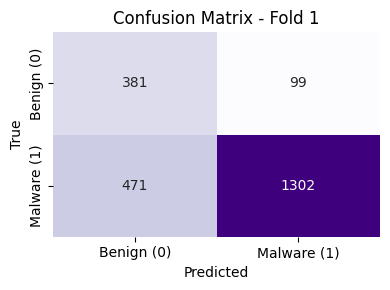

-------------------------------------------------------

======================= FOLD 2 ======================
Overall Accuracy: 0.7131
Class       Precision   Recall      F1-Score    
Benign (0)  0.4105      0.7996      0.5425      
Malware (1) 0.9272      0.6898      0.7911      


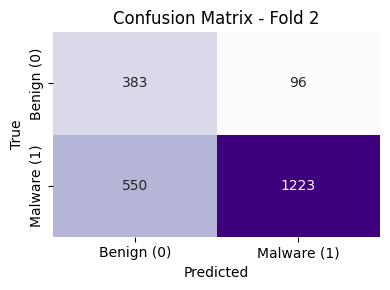

-------------------------------------------------------

======================= FOLD 3 ======================
Overall Accuracy: 0.7664
Class       Precision   Recall      F1-Score    
Benign (0)  0.4715      0.7917      0.5910      
Malware (1) 0.9308      0.7596      0.8365      


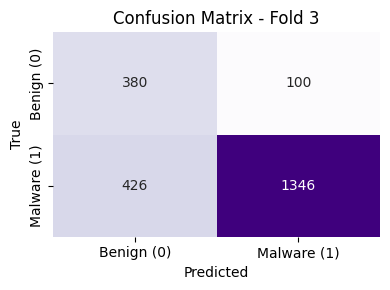

-------------------------------------------------------

======================= FOLD 4 ======================
Overall Accuracy: 0.7518
Class       Precision   Recall      F1-Score    
Benign (0)  0.4504      0.7479      0.5623      
Malware (1) 0.9168      0.7528      0.8268      


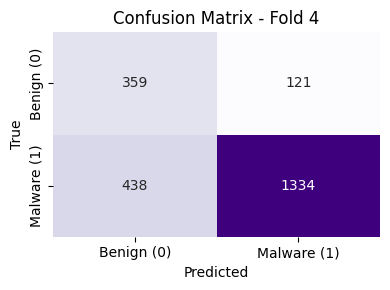

-------------------------------------------------------

======================= FOLD 5 ======================
Overall Accuracy: 0.7291
Class       Precision   Recall      F1-Score    
Benign (0)  0.4265      0.7854      0.5528      
Malware (1) 0.9247      0.7139      0.8057      


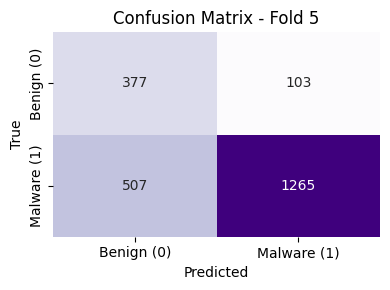

-------------------------------------------------------


==================== FINAL NAIVE BAYES 5-FOLD AVERAGE REPORT ====================
Mean Accuracy: 0.7415 (+/- 0.0185)
------------------------------------------------------------
Metric              Benign (Class 0)      Malware (Class 1)     
Mean Precision      0.4412                0.9258                
Mean Recall         0.7837                0.7301                
Mean F1-Score       0.5641                0.8161                


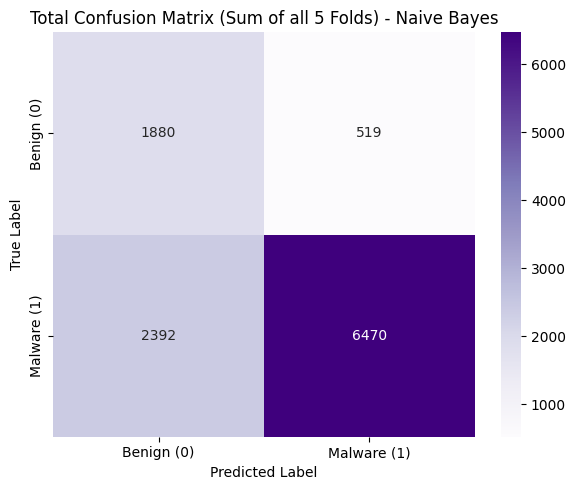

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

# 1. Load the top 30 features dataset
file_part3 = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 3/malware_top_30_dependencies.csv'
df_top30 = pd.read_csv(file_part3)

# Separate features (X) and target (y)
# Notice: We do NOT apply StandardScaler here
X = df_top30.drop(columns=['OUTPUT']).values
y = df_top30['OUTPUT'].values

# 2. Setup Stratified 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionaries to store all metrics across folds for final averaging
metrics_history = {
    'accuracy': [],
    'precision_0': [], 'precision_1': [],
    'recall_0': [], 'recall_1': [],
    'f1_0': [], 'f1_1': []
}

# Cumulative confusion matrix for the final plot
combined_cm = np.zeros((2, 2), dtype=int)

print("Starting 5-Fold Cross Validation for Naive Bayes (No Scaling Applied)...\n")

# 3. Loop through each fold
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Initialize Multinomial Naive Bayes
    # fit_prior=True allows the model to learn class prior probabilities from the imbalanced data
    nb_model = MultinomialNB(fit_prior=True)
    nb_model.fit(X_train, y_train)

    # Predict
    y_pred = nb_model.predict(X_test)

    # Calculate Metrics
    fold_acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=[0, 1])
    fold_cm = confusion_matrix(y_test, y_pred)

    # Save to history
    metrics_history['accuracy'].append(fold_acc)
    metrics_history['precision_0'].append(precision[0])
    metrics_history['precision_1'].append(precision[1])
    metrics_history['recall_0'].append(recall[0])
    metrics_history['recall_1'].append(recall[1])
    metrics_history['f1_0'].append(f1[0])
    metrics_history['f1_1'].append(f1[1])

    combined_cm += fold_cm

    # --- Print Individual Fold Metrics Table ---
    print(f"======================= FOLD {fold} ======================")
    print(f"Overall Accuracy: {fold_acc:.4f}")
    print(f"{'Class':<12}{'Precision':<12}{'Recall':<12}{'F1-Score':<12}")
    print(f"{'Benign (0)':<12}{precision[0]:<12.4f}{recall[0]:<12.4f}{f1[0]:<12.4f}")
    print(f"{'Malware (1)':<12}{precision[1]:<12.4f}{recall[1]:<12.4f}{f1[1]:<12.4f}")

    # Plot Confusion Matrix for this fold
    plt.figure(figsize=(4, 3))
    sns.heatmap(fold_cm, annot=True, fmt='d', cmap='Purples', cbar=False,
                xticklabels=['Benign (0)', 'Malware (1)'],
                yticklabels=['Benign (0)', 'Malware (1)']) # retain
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
    print("-" * 55 + "\n")

# ==========================================================
# 4. Final Summary & Overall Averages
# ==========================================================
print("\n" + "="*20 + " FINAL NAIVE BAYES 5-FOLD AVERAGE REPORT " + "="*20)
print(f"Mean Accuracy: {np.mean(metrics_history['accuracy']):.4f} (+/- {np.std(metrics_history['accuracy']):.4f})")
print("-" * 60)
print(f"{'Metric':<20}{'Benign (Class 0)':<22}{'Malware (Class 1)':<22}")
print(f"{'Mean Precision':<20}{np.mean(metrics_history['precision_0']):<22.4f}{np.mean(metrics_history['precision_1']):<22.4f}")
print(f"{'Mean Recall':<20}{np.mean(metrics_history['recall_0']):<22.4f}{np.mean(metrics_history['recall_1']):<22.4f}")
print(f"{'Mean F1-Score':<20}{np.mean(metrics_history['f1_0']):<22.4f}{np.mean(metrics_history['f1_1']):<22.4f}")
print("=" * 69)

# ==========================================================
# 5. Combined Confusion Matrix (Total of all folds)
# ==========================================================
plt.figure(figsize=(6, 5))
sns.heatmap(combined_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign (0)', 'Malware (1)'],
            yticklabels=['Benign (0)', 'Malware (1)'])
plt.title('Total Confusion Matrix (Sum of all 5 Folds) - Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()